## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
alc_data = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")

In [ ]:
alc_data.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9


## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [ ]:
alc_data = alc_data.drop("total_litres_of_pure_alcohol", axis=1)

In [ ]:
alc_tidy = alc_data.melt(
    id_vars = "country",
    var_name = "drink",
    value_name = "servings"
)
alc_tidy.head()

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

In [ ]:
alc_tidy["drink"] = alc_tidy["drink"].str.replace("_servings", "", regex = False)
alc_tidy.head()
alc_tidy.tail()

,country,drink,servings
574,Venezuela,wine,3
575,Vietnam,wine,1
576,Yemen,wine,0
577,Zambia,wine,4
578,Zimbabwe,wine,4


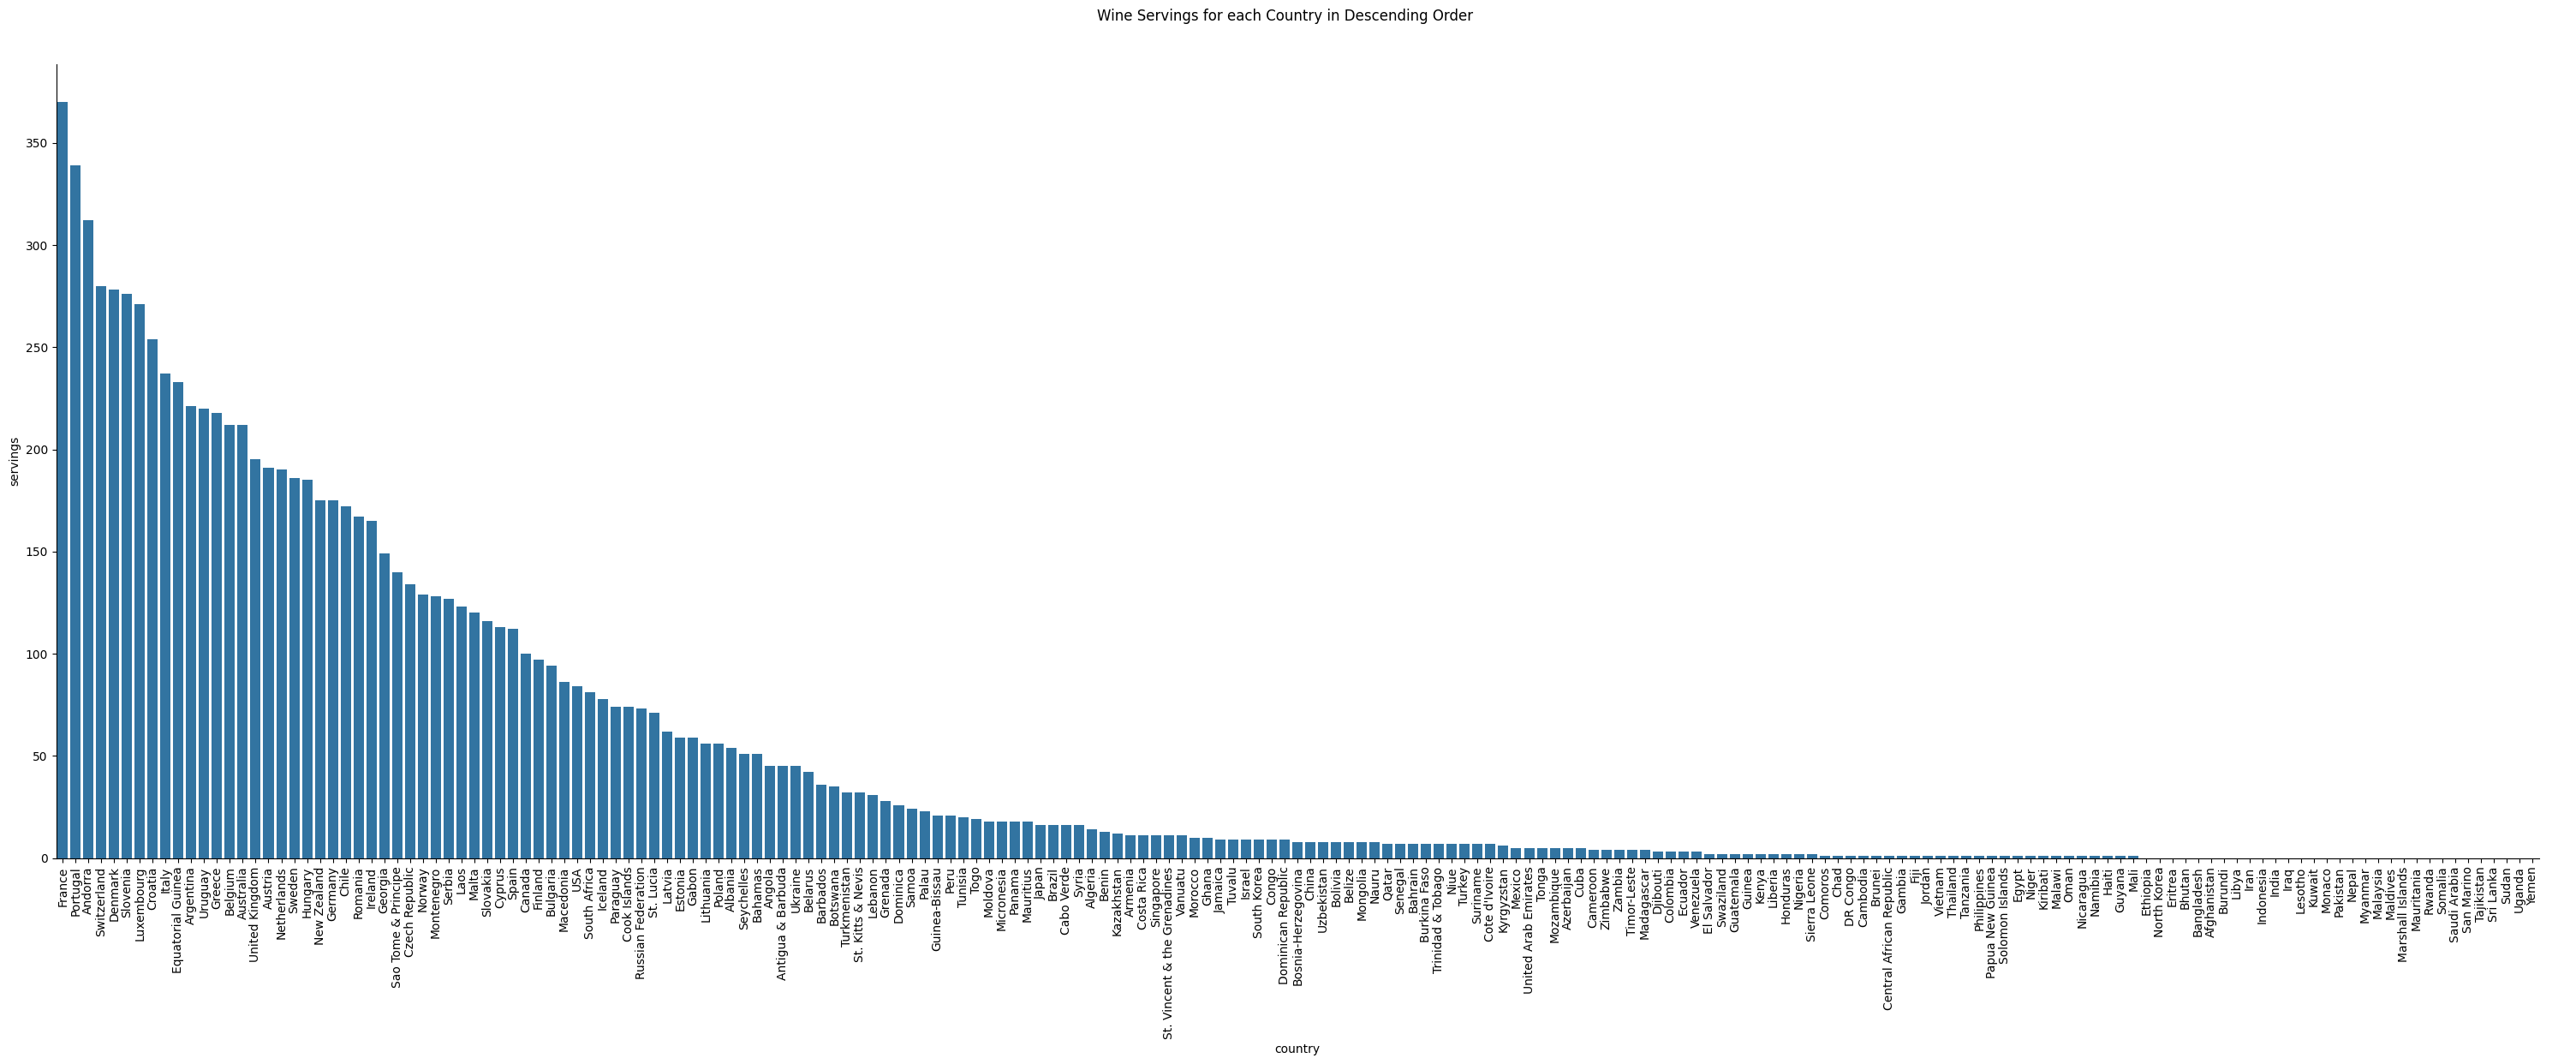

In [ ]:
wine_tidy = alc_tidy[alc_tidy['drink'] == 'wine']
wine_tidy = wine_tidy.sort_values("servings", ascending = False)

g1 = sns.catplot(
    data = wine_tidy,
    x = 'country',
    y = "servings",
    kind = "bar",
    aspect = 3,
    height = 10,
)
g1.tick_params(axis = 'x', rotation = 90)

g1.fig.suptitle("Wine Servings for each Country in Descending Order", y = 1.05);
'''
Top 10 wine drinking countries:
1) France
2) Portugal
3) Andorra
4) Switzerland
5) Denmark
6) Slovenia
7) Luxemborg
8) Croatia
9) Italy
10) Equatorial Guinea
''';

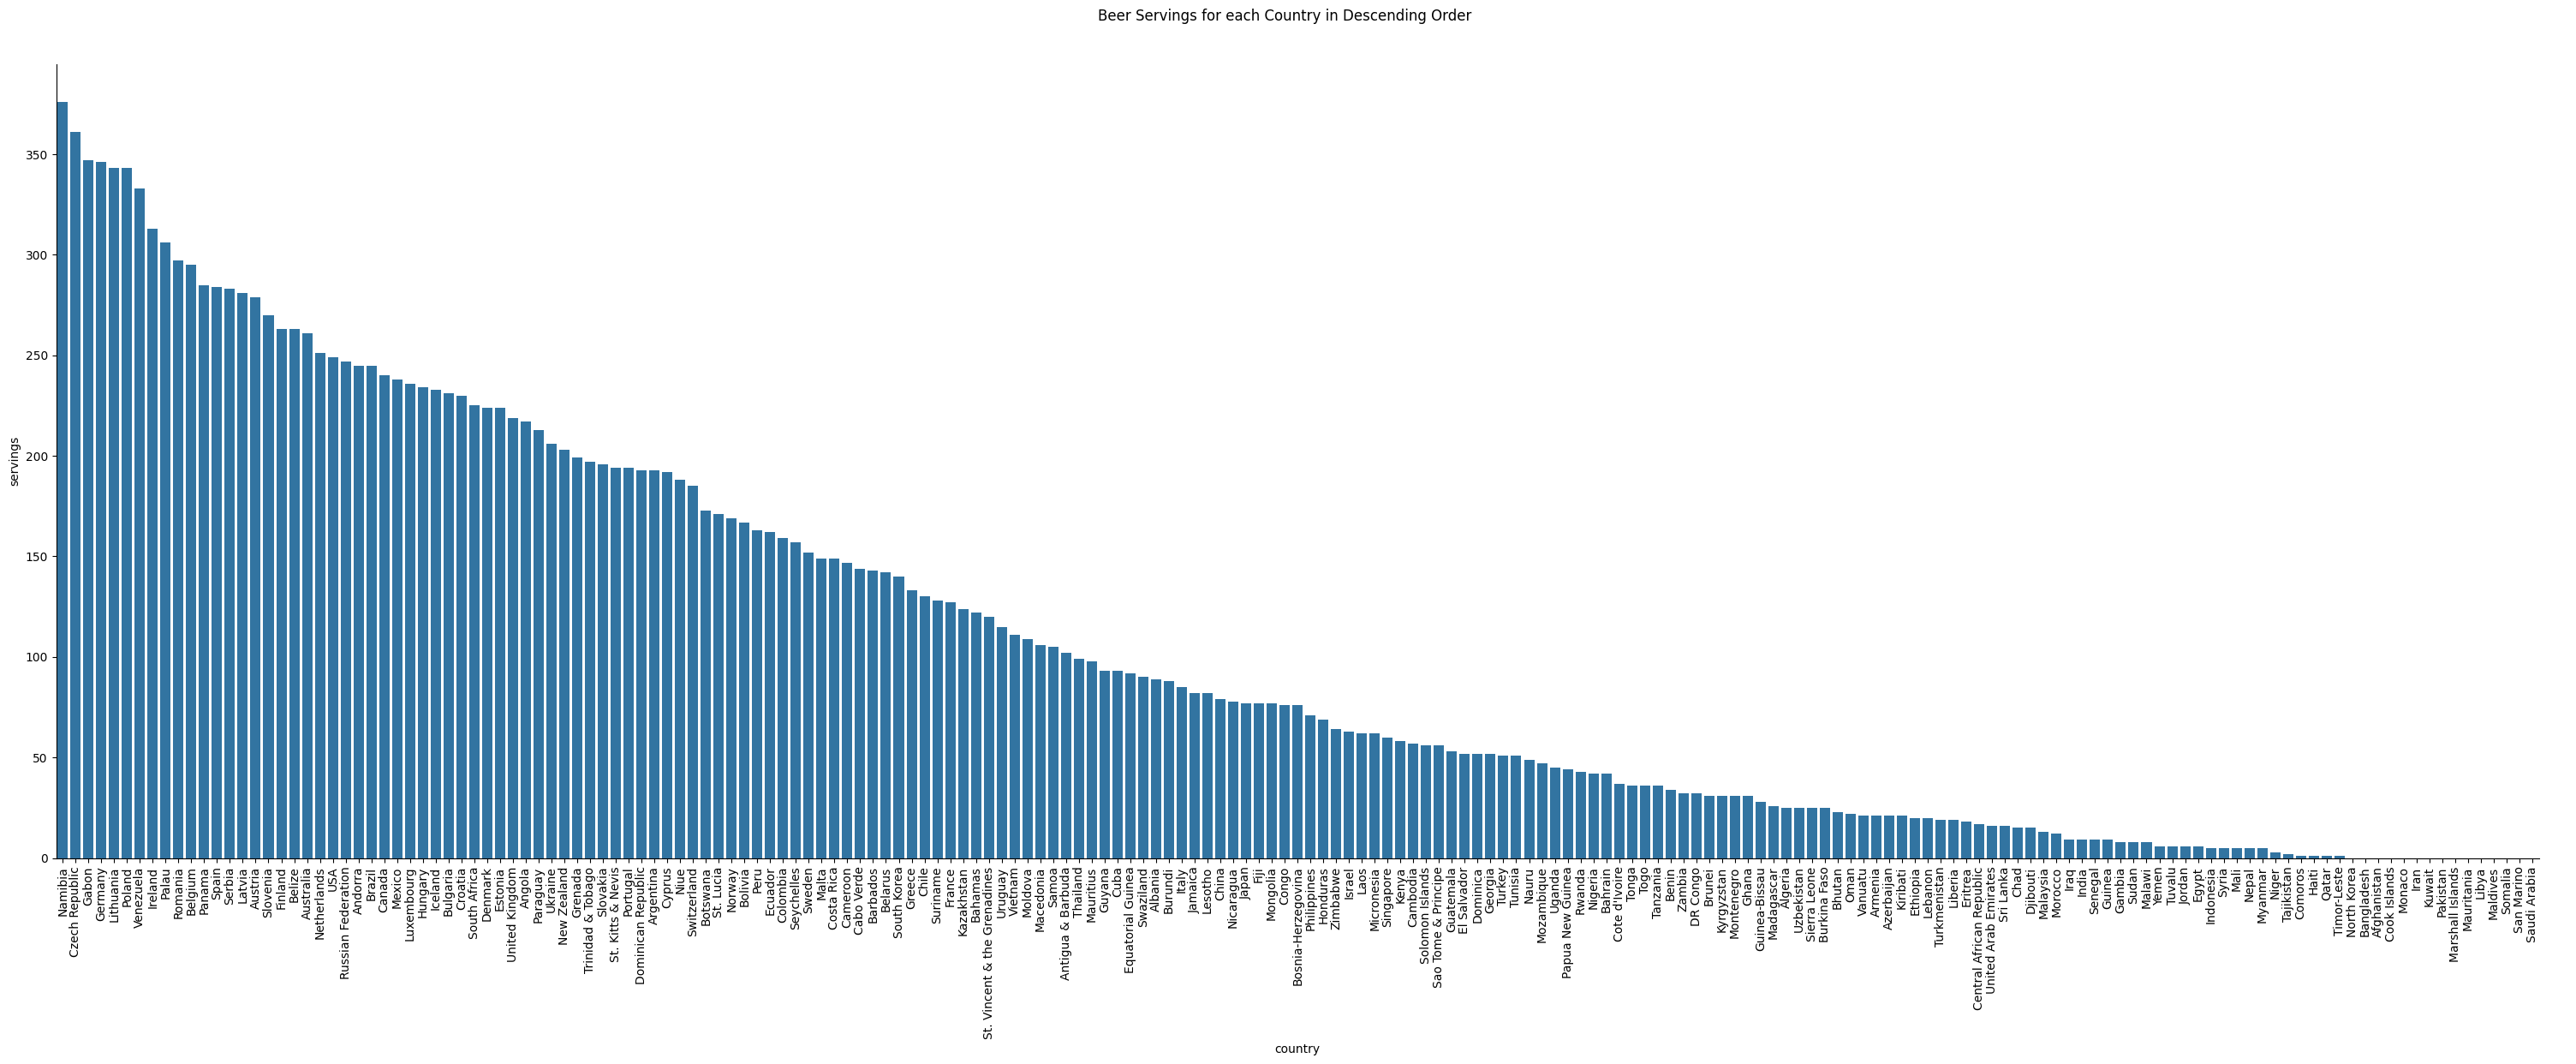

In [ ]:
beer_tidy = alc_tidy[alc_tidy['drink'] == 'beer']
beer_tidy = beer_tidy.sort_values("servings", ascending = False)

g2 = sns.catplot(
    data = beer_tidy,
    x = 'country',
    y = "servings",
    kind = "bar",
    aspect = 3,
    height = 10,
)
g2.tick_params(axis = 'x', rotation = 90)

g2.fig.suptitle("Beer Servings for each Country in Descending Order", y = 1.05)

'''
Top 10 Beer drinking countries:
1) Namibia
2) Czech Republic
3) Gabon
4) Germany
5) Lithuania
6) Poland
7) Venezuela
8) Ireland
9) Palau
10) Romania
''';

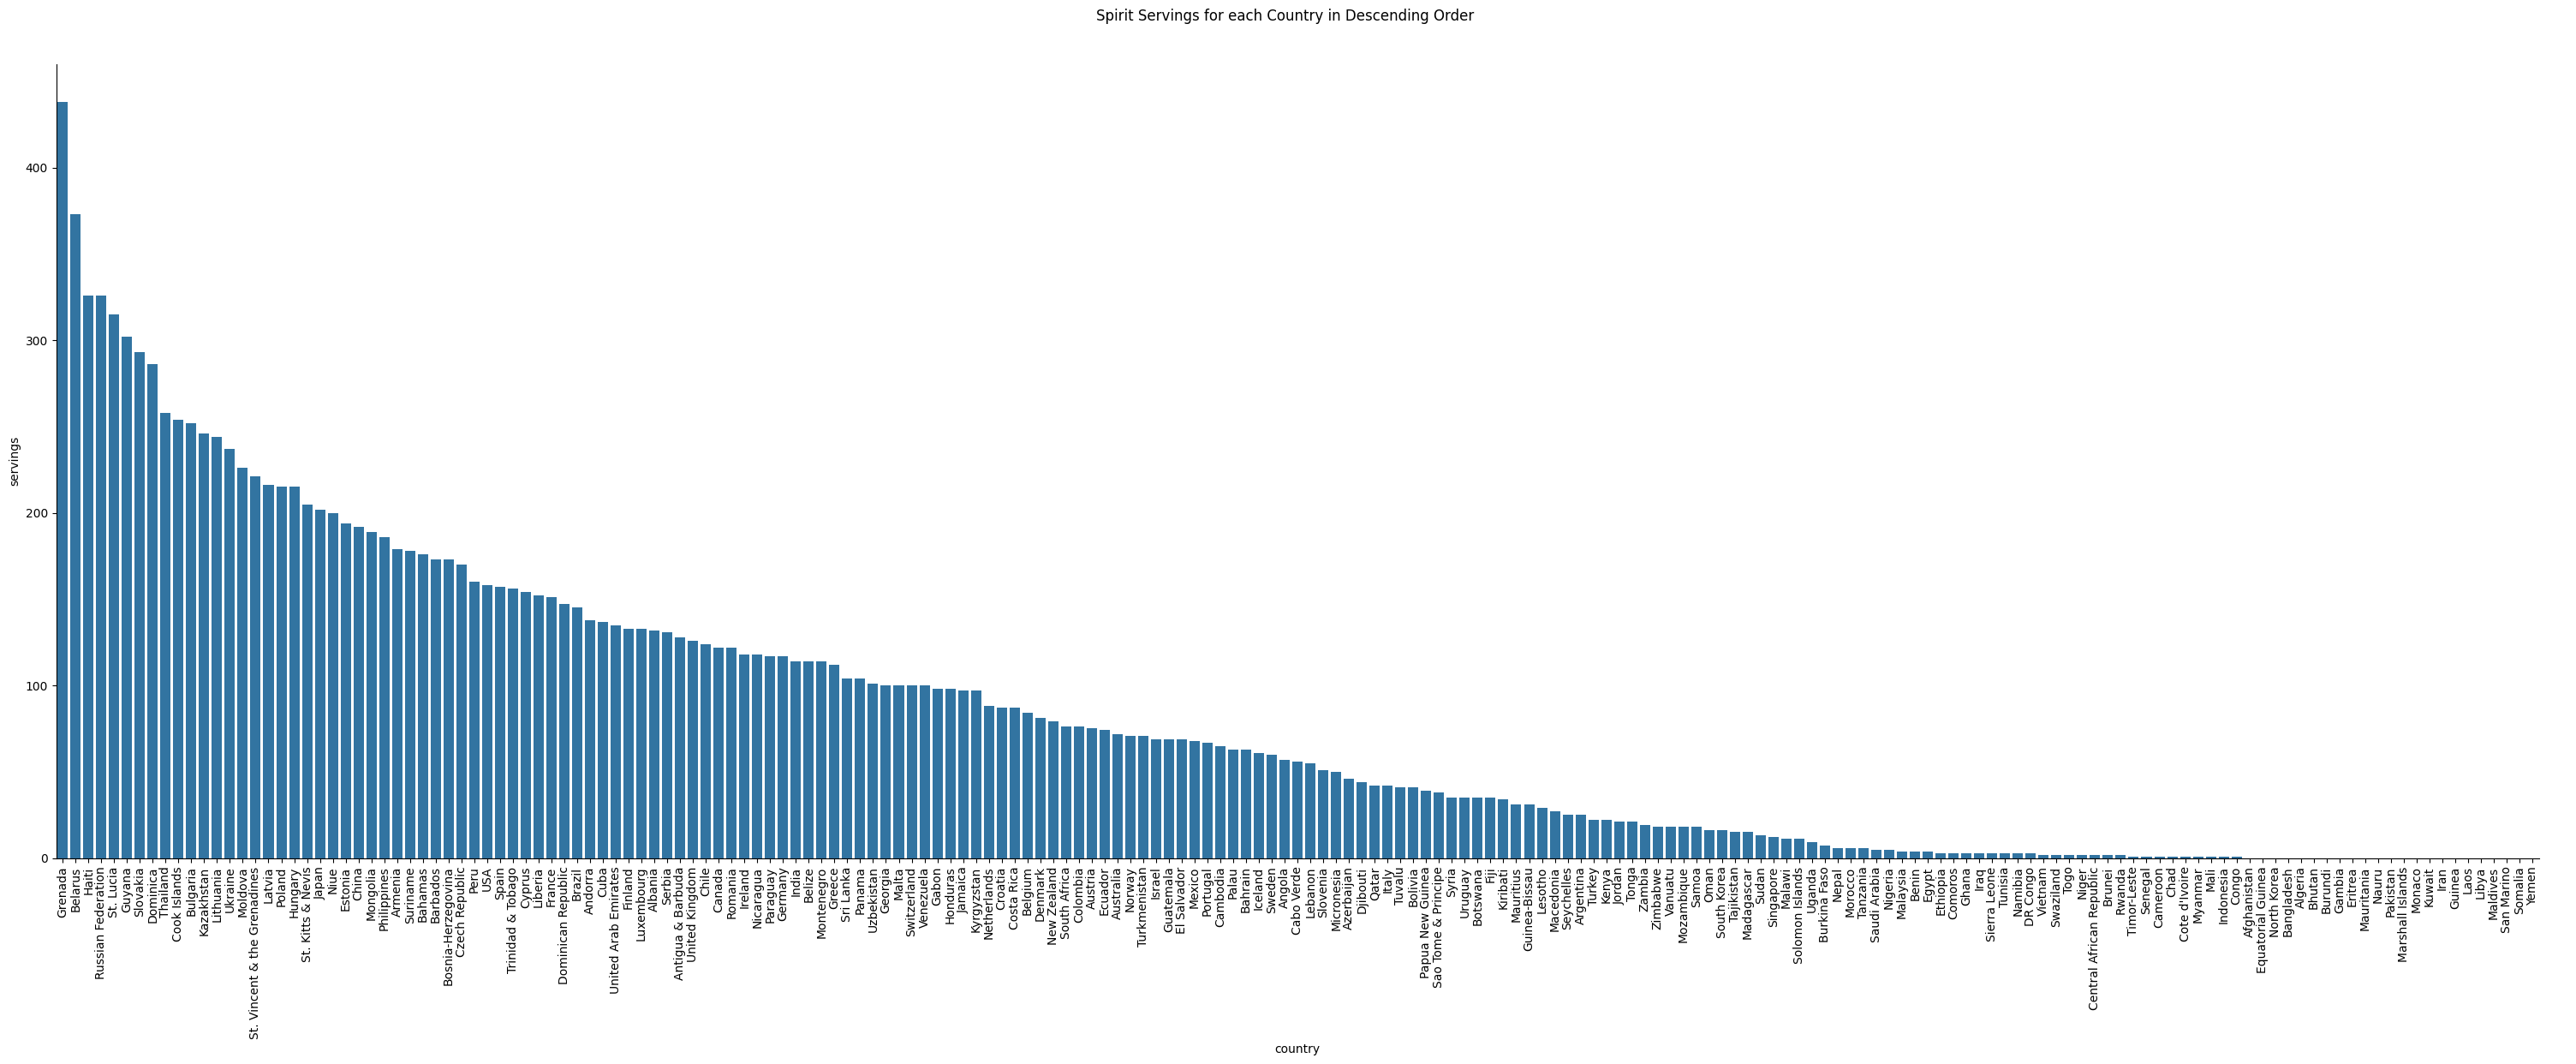

In [ ]:
spirit_tidy = alc_tidy[alc_tidy['drink'] == 'spirit']
spirit_tidy = spirit_tidy.sort_values("servings", ascending = False)

g3 = sns.catplot(
    data = spirit_tidy,
    x = 'country',
    y = "servings",
    kind = "bar",
    aspect = 3,
    height = 10,
)
g3.tick_params(axis = 'x', rotation = 90)
g3.fig.suptitle("Spirit Servings for each Country in Descending Order", y = 1.05)

'''
Top 10 Spirit Drinking Countries:
1) Grenada
2) Belarus
3) Haiti
4) Russian Federation
5) St. Lucia
6) Guyana
7) Slovakia
8) Dominica
9) Thailand
10) Cook Islands
''';

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [ ]:
pd.pivot_table(alc_tidy, index = "drink", columns = "country", values = ["drink", "servings"])

servings                                                   \
country Afghanistan Albania Algeria Andorra Angola Antigua & Barbuda   
drink                                                                  
beer            0.0    89.0    25.0   245.0  217.0             102.0   
spirit          0.0   132.0     0.0   138.0   57.0             128.0   
wine            0.0    54.0    14.0   312.0   45.0              45.0   

                                             ...                       \
country Argentina Armenia Australia Austria  ... United Arab Emirates   
drink                                        ...                        
beer        193.0    21.0     261.0   279.0  ...                 16.0   
spirit       25.0   179.0      72.0    75.0  ...                135.0   
wine        221.0    11.0     212.0   191.0  ...                  5.0   

                                                                           \
country United Kingdom Uruguay Uzbekistan Vanuatu Venezuela Vietnam Yemen   
drink                                                                       
beer             219.0   115.0       25.0    21.0     333.0   111.0   6.0   
spirit           126.0    35.0      101.0    18.0     100.0     2.0   0.0   
wine             195.0   220.0        8.0    11.0       3.0     1.0   0.0   

                         
country Zambia Zimbabwe  
drink                    
beer      32.0     64.0  
spirit    19.0     18.0  
wine       4.0      4.0  

[3 rows x 193 columns]